## Non LLM based parallel workflow
### Employee info

In [13]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated

In [19]:
class EmployeeState(TypedDict):
    emp_name: str
    monthly_salary:int
    working_days:int
    completed_projects:int

    yearly_salary:int
    bonus_amount:int
    project_status:str
    summary:str
    

In [23]:
def calculate_bonus(state:EmployeeState):
    return {
        "bonus_amount":state["monthly_salary"] * 2
    }

def calculate_yearly_salary(state:EmployeeState)->EmployeeState:
    return {
        "yearly_salary":state["monthly_salary"] * 12
    }

def project_evaluation(state:EmployeeState)->EmployeeState:
    pro=state["completed_projects"]
    if pro>=5:
        status="Excellent"
    else:
        status="Average"
    return {
        "project_status":status
    }

def summary(state:EmployeeState)->EmployeeState:
    summary_text=f"Employee {state["emp_name"]} has a yearly salry of {state["yearly_salary"]} and a bonus of {state["bonus_amount"]}. Project status is {state["project_status"]}"
    return {
        "summary":summary_text
    }



In [25]:
graph=StateGraph(EmployeeState)

graph.add_node("calculate_bonus",calculate_bonus)
graph.add_node("calculate_yearly_salary",calculate_yearly_salary)
graph.add_node("project_evaluation",project_evaluation)
graph.add_node("summary",summary)


graph.add_edge(START,"calculate_bonus")
graph.add_edge(START,"calculate_yearly_salary")
graph.add_edge(START,"project_evaluation")
graph.add_edge("calculate_bonus","summary")
graph.add_edge("calculate_yearly_salary","summary")
graph.add_edge("project_evaluation","summary")
graph.add_edge("summary",END)

workflow=graph.compile()
workflow

ValueError: Failed to reach https://mermaid.ink API while trying to render your graph after 1 retries. To resolve this issue:
1. Check your internet connection and try again
2. Try with higher retry settings: `draw_mermaid_png(..., max_retries=5, retry_delay=2.0)`
3. Use the Pyppeteer rendering method which will render your graph locally in a browser: `draw_mermaid_png(..., draw_method=MermaidDrawMethod.PYPPETEER)`

In [26]:
initial_state={
    "emp_name":"Rajesh",
    "monthly_salary":78000,
    "working_days":27,
    "completed_projects":7

}

final_state=workflow.invoke(initial_state)

In [30]:
from pprint import pprint
pprint(final_state)

{'bonus_amount': 156000,
 'completed_projects': 7,
 'emp_name': 'Rajesh',
 'monthly_salary': 78000,
 'project_status': 'Excellent',
 'summary': 'Employee Rajesh has a yearly salry of 936000 and a bonus of '
            '156000. Project status is Excellent',
 'working_days': 27,
 'yearly_salary': 936000}


## LLM Based Parallel Workflow\
### Essay Workflow

In [59]:
from dotenv import load_dotenv
load_dotenv()

True

In [60]:
from langchain.chat_models import init_chat_model
model=init_chat_model(
    "openai/gpt-oss-120b",
    model_provider="groq",
    temperature=0.5
)
print(model.invoke("Hi"))

content='Hello! How can I help you today?' additional_kwargs={'reasoning_content': 'The user says "Hi". We need to respond appropriately. There\'s no policy violation. Just greet.'} response_metadata={'token_usage': {'completion_tokens': 39, 'prompt_tokens': 72, 'total_tokens': 111, 'completion_time': 0.080615718, 'completion_tokens_details': {'reasoning_tokens': 21}, 'prompt_time': 0.003339881, 'prompt_tokens_details': None, 'queue_time': 0.394591267, 'total_time': 0.083955599}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_9241e9962b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--01a0e3cc-da60-70b1-8be4-c765c076df8a-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 72, 'output_tokens': 39, 'total_tokens': 111, 'output_token_details': {'reasoning': 21}}


In [61]:
from pydantic import BaseModel,Field
import operator

In [62]:
class EvaluateSchema(BaseModel):
    feedback:str=Field(description="Detailed feedback of the essay")
    score:int=Field(description="Score out of 10",ge=0,le=10)

structured_model=model.with_structured_output(EvaluateSchema)

In [63]:
class EssayState(TypedDict):
    essay:str
    analysis_feedback:str
    language_feedback:str
    thought_feedback:str
    finaleval_feedback:str
    individual_scores:Annotated[list[int],operator.add]
    average_score:float

In [64]:
def evaluate_analysis(state:EssayState):
    prompt=f"""Evaluate the following essay for the quality, correctness, depth, and logical consistency of its analysis. Identify strengths, weaknesses, missing arguments, and reasoning errors. Give an integer score from 0 to 10. Do not use decimal values.
Essay: {state["essay"]}"""
    response=structured_model.invoke(prompt)
    return {
        "analysis_feedback":response.feedback,
        "individual_scores":[response.score]
    }

def evaluate_language(state:EssayState):
    prompt=f"""Evaluate the following essay for grammar, vocabulary, sentence structure, clarity, coherence, readability, and overall quality of language. Identify errors and areas for improvement. Give an integer score from 0 to 10. Do not use decimal values.
    Essay: {state["essay"]}"""
    response=structured_model.invoke(prompt)
    return {
        "language_feedback":response.feedback,
        "individual_scores":[response.score]
    }

def evaluate_thought(state:EssayState):
    prompt=f"""Evaluate the reasoning and thought process presented in the following essay. Assess whether the arguments are logical, well-structured, sufficiently supported, and free from contradictions or unsupported conclusions. Give an integer score from 0 to 10. Do not use decimal values.
    Essay: {state["essay"]}"""
    response=structured_model.invoke(prompt)
    return {
        "thought_feedback":response.feedback,
        "individual_scores":[response.score]
    }

def finaleval_feedback(state:EssayState):
    prompt=f"""Based on the outputs from the analysis, language, and thought evaluation nodes, provide a final evaluation of the essay. Summarize the key strengths, weaknesses, and specific improvements needed. Give an integer score from 0 to 10. Do not use decimal values.
    Analysis Evaluation: {state["analysis_feedback"]}
    Language Evaluation: {state["language_feedback"]}
    Thought Evaluation: {state["thought_feedback"]}"""
    response=model.invoke(prompt)
    avg_score=sum(state["individual_scores"])/len(state["individual_scores"])
    return {
        "finaleval_feedback":response,
        "average_score":avg_score
    }

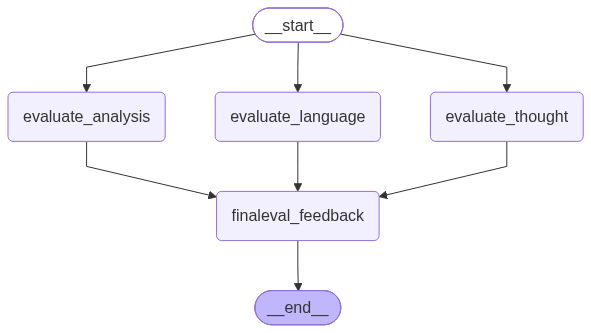

In [65]:
graph=StateGraph(EssayState)

graph.add_node("evaluate_analysis",evaluate_analysis)
graph.add_node("evaluate_language",evaluate_language)
graph.add_node("evaluate_thought",evaluate_thought)
graph.add_node("finaleval_feedback",finaleval_feedback)


graph.add_edge(START,"evaluate_analysis")
graph.add_edge(START,"evaluate_language")
graph.add_edge(START,"evaluate_thought")
graph.add_edge("evaluate_analysis","finaleval_feedback")
graph.add_edge("evaluate_language","finaleval_feedback")
graph.add_edge("evaluate_thought","finaleval_feedback")
graph.add_edge("finaleval_feedback",END)

workflow=graph.compile()
workflow

In [66]:
essay="""Topic: The Impact of Artificial Intelligence on Education

Artificial Intelligence (AI) is transforming the education sector by changing how students learn and how teachers deliver knowledge. AI-powered tools can provide personalized learning experiences, answer students' questions, generate educational content, and help teachers analyze student performance.

One of the major advantages of AI in education is personalized learning. Traditional classrooms often use the same teaching approach for all students, even though students have different learning speeds and abilities. AI systems can analyze a student's performance and recommend suitable learning materials based on their individual needs.

However, the use of AI also creates certain challenges. Students may become overly dependent on AI tools and stop developing their own problem-solving and critical-thinking skills. There are also concerns about incorrect information, data privacy, and the ethical use of AI-generated content.

Therefore, AI should be used as a supporting tool rather than a complete replacement for teachers or independent learning. When used responsibly, AI can make education more personalized, accessible, and effective while allowing teachers to focus more on mentoring and interaction with students."""

In [67]:
initial_state={
    "essay":essay,
}
final_state=workflow.invoke(initial_state)
pprint(final_state)

{'analysis_feedback': 'The essay provides a clear, concise overview of AI’s '
                      'impact on education. It correctly identifies key '
                      'benefits such as personalized learning, content '
                      'generation, and data‑driven assessment, and it '
                      'acknowledges important challenges including '
                      'over‑reliance, misinformation, privacy, and ethics. The '
                      'argument is logically structured: a brief introduction, '
                      'a discussion of advantages, a counterpoint on '
                      'drawbacks, and a concluding recommendation that AI be '
                      'used as a supportive tool.\n'
                      '\n'
                      '**Strengths**\n'
                      '- **Clarity and organization**: The essay follows a '
                      'logical flow and uses topic sentences that guide the '
                      'reader.\n'
             

In [68]:
final_state

{'essay': "Topic: The Impact of Artificial Intelligence on Education\n\nArtificial Intelligence (AI) is transforming the education sector by changing how students learn and how teachers deliver knowledge. AI-powered tools can provide personalized learning experiences, answer students' questions, generate educational content, and help teachers analyze student performance.\n\nOne of the major advantages of AI in education is personalized learning. Traditional classrooms often use the same teaching approach for all students, even though students have different learning speeds and abilities. AI systems can analyze a student's performance and recommend suitable learning materials based on their individual needs.\n\nHowever, the use of AI also creates certain challenges. Students may become overly dependent on AI tools and stop developing their own problem-solving and critical-thinking skills. There are also concerns about incorrect information, data privacy, and the ethical use of AI-genera